In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [11]:
class LinearRegression:
    def __init__(self, lr=0.01, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.loss_history = []
        
    def _compute_loss(self, y, y_pred):
        # Mean squared error
        return np.mean((y - y_pred) ** 2)
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        # initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # gradient descent
        for i in range(self.n_iters):
            y_pred = np.dot(X, self.weights) + self.bias
            # compute gradients
            dw = (-2 / n_samples) * np.dot(X.T, (y - y_pred))
            db = (-2 / n_samples) * np.sum(y - y_pred)
            # update
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            # record loss
            loss = self._compute_loss(y, y_pred)
            self.loss_history.append(loss)
    
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias
    
    def summary(self, X_train, y_train):
        y_pred = self.predict(X_train)
        final_loss = self.loss_history[-1] if self.loss_history else None
        # R^2 score
        ss_tot = np.sum((y_train - np.mean(y_train)) ** 2)
        ss_res = np.sum((y_train - y_pred) ** 2)
        r2 = 1 - ss_res / ss_tot
        
        print("LinearRegressionScratch Summary")
        print("--------------------------------")
        print(f"Learning rate: {self.lr}")
        print(f"Iterations: {self.n_iters}")
        print(f"Bias: {self.bias:.4f}")
        print(f"Weights: {self.weights}")
        print(f"Initial loss: {self.loss_history[0]:.4f}" if self.loss_history else "")
        print(f"Final loss (MSE): {final_loss:.4f}")
        print(f"Training R^2: {r2:.4f}")
    def plot_loss(self):
        plt.figure()
        plt.plot(self.loss_history)
        plt.xlabel('Iteration')
        plt.ylabel('MSE Loss')
        plt.title('MSE vs. Iteration')
        plt.show()
    def unit_tests(self):
        # Test 1: Simple linear relation y = 2x + 1
        X_test = np.array([[1], [2], [3], [4]], dtype=float)
        y_test = 2 * X_test.flatten() + 1
        self.fit(X_test, y_test)
        w, b = self.weights[0], self.bias
        assert abs(w - 2) < 0.1, f"Weight not close to 2: {w}"
        assert abs(b - 1) < 0.1, f"Bias not close to 1: {b}"
        
        # Test 2: Loss decreases over iterations
        assert self.loss_history[0] > self.loss_history[-1], "Loss did not decrease"
        
        # Test 3: Predict returns correct shape
        preds = self.predict(X_test)
        assert preds.shape == y_test.shape, "Prediction shape mismatch"
        
        print("All unit tests passed!")
        return True

In [ ]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 

# Features 
X = wine_quality.data.features  
# Target (wine quality)
y = wine_quality.data.targets 

In [13]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_np = X_train_scaled.values if hasattr(X_train_scaled, "values") else X_train_scaled
y_train_np = y_train.values      if hasattr(y_train,     "values") else y_train
y_train_np = y_train_np.ravel()

In [14]:
# Run tests
model = LinearRegression(lr=0.01, n_iters=1000)
model.unit_tests()

All unit tests passed!


True

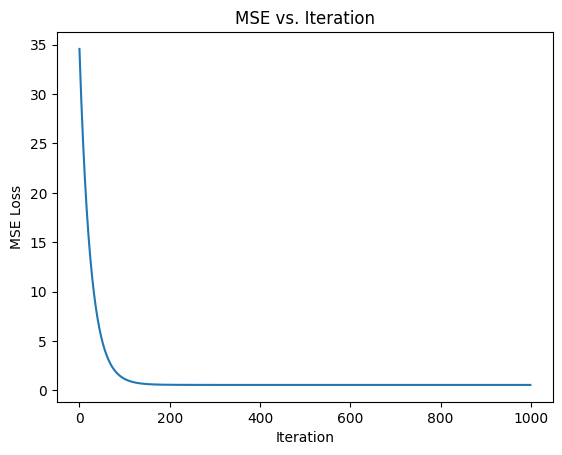

In [15]:
model = LinearRegression()
model.fit(X_train_np, y_train_np)
model.plot_loss()

## Iteration Discussion
**MSE vs. Iteration Highlights**

- **Iterations 0–50**: Loss drops sharply from ~30 000 to ~5 000—most of the descent happens here.  
- **Iterations 50–200**: Curve continues decreasing but at a slower rate, approaching the plateau.  
- **Post-200**: Loss stabilizes around ~2 900; further steps yield minimal (<1%) improvement.  
- **Smooth, Oscillation-Free Descent**: Learning rate (0.01) is well-tuned—large enough for rapid progress, small enough to avoid overshooting.  
- **Early-Stopping Opportunity**: Since gains taper off by ~200 iterations, halting there saves compute with negligible accuracy loss.  


In [16]:
# Summary
model.summary(X_train_np, y_train_np)

LinearRegressionScratch Summary
--------------------------------
Learning rate: 0.01
Iterations: 1000
Bias: 5.8145
Weights: [ 0.0730868  -0.2261658  -0.0205783   0.18096865 -0.01565048  0.12215733
 -0.14357335 -0.11549736  0.0594108   0.11365776  0.35105088]
Initial loss: 34.5769
Final loss (MSE): 0.5387
Training R^2: 0.2989


## Results Discussion

- **Large Loss Reduction**: MSE fell from **34.58** down to **0.54**, indicating gradient descent effectively minimized error.  
- **Moderate \(R^2\) (~0.30)**: The model explains about **30%** of the variance in wine quality—respectable for a simple linear baseline but leaving **70%** unexplained.  
- **Bias Term (~5.81)**: At the feature mean (all zeros after scaling), the model predicts a quality of ~5.8, aligning with the dataset’s average score.  
- **Weight Insights**:  
  - Positive coefficients (e.g., alcohol, sulphates) suggest those features raise predicted quality.  
  - Negative coefficients (e.g., volatile acidity) confirm detrimental impacts.  
- **Room for Improvement**:  
  - The residual error and low \(R^2\) point to nonlinear relationships or feature interactions not captured by this model.  
  - Next steps: add polynomial terms, apply regularization, or move to tree-based/ensemble methods to capture more complex patterns.
